## Methodology

### Prediction target
Predicting P(YES) for each market, then comparing the model's prediction
against `prev_day_price` (the market's own 1-day-before-resolution price).
Large disagreements between model and market = mispricing candidates.

### Features
- `prev_day_price`: observed at prediction time. Doesn't leak. This is the
  market's own forecast — the thing we're trying to improve on.
- `category` (one-hot encoded): known at market creation. Doesn't leak.
  Day 2 showed Sports and Crypto are the miscalibrated categories, so this
  feature is critical.
- `volume`: total market volume, known at prediction time. Doesn't leak.
  Including it because high-volume markets may be better-priced (more
  participants → better information aggregation), so the model can learn
  to weight the market's signal more when volume is high.
- `lifetime_days`: known at prediction time. Technically off by roughly a day
  from the full lifetime (we'd know "current lifetime" not final), but the
  difference is negligible.

### Cross-validation
- Initially attempted a chronological 80/20 train/test split (markets sorted by 
  `closed_time`). This produced extreme category drift — Polymarket's market mix 
  shifted over time, so categories like Geopolitics had 0 markets in train but 
  appeared in test.
- Switched to a stratified random 80/20 split on `category × outcome` to preserve 
  category proportions across the split. Trade-off: cannot claim future-market 
  generalization. Gain: meaningful within-distribution evaluation.

### Models
- **Logistic regression** as baseline — interpretable, but can't capture
  interactions like (Sports × high price) without manual feature engineering.
- **Random forest** as the main model — captures category × price
  interactions automatically, which is the exact pattern I noticed
  as the main source of mispricing.
- Both models trained on the same train split, evaluated on the same test.

### Evaluation metrics
- **Aggregate Brier** on the holdout. Baseline to beat
  is the market's own Brier of 0.162. If the model's Brier isn't lower
  than that on the test set, we haven't found mispricing.
- **Log loss** on the holdout — secondary metric
- **Per-category Brier** — aggregate Brier might hide that the model is
  great at Politics but useless at Sports, where the actual mispricing
  lives.
- **Calibration plot** on the holdout, with model and market overlaid.
- **Direct head-to-head**: compute Brier and log loss for (a) the market's
  `prev_day_price`, (b) the model's prediction, on identical test rows.

In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("resolved_markets.csv")

df['created_at'] = pd.to_datetime(df['created_at'], format='ISO8601')
df['closed_time'] = pd.to_datetime(df['closed_time'], format='ISO8601')
df['lifetime_days'] = (df['closed_time'] - df['created_at']).dt.days
df['prev_day_price'] = df['last_trade_price'] - df['one_day_price_change']

eligible = df[(df['lifetime_days'] >= 1) & (df['volume'] >= 100) & (df['prev_day_price'] > 0) & (df['prev_day_price'] < 1)].copy()

eligible = eligible.sort_values('closed_time').reset_index(drop=True)

category_dummies = pd.get_dummies(eligible['category'], prefix='cat')

X = pd.concat([eligible[['prev_day_price', 'volume','lifetime_days']], category_dummies], axis=1)

y = eligible['yes_resolved']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y mean (base rate): {y.mean():.3f}")
print(f"\nFeatures ({len(X.columns)}): {list(X.columns)}")
print(f"\nFirst row of X:")
print(X.iloc[0])

X shape: (2355, 10)
y shape: (2355,)
y mean (base rate): 0.341

Features (10): ['prev_day_price', 'volume', 'lifetime_days', 'cat_Crypto', 'cat_Finance', 'cat_Geopolitics', 'cat_Other', 'cat_Politics', 'cat_Sports', 'cat_Weather']

First row of X:
prev_day_price           0.5
volume             362.95459
lifetime_days              1
cat_Crypto              True
cat_Finance            False
cat_Geopolitics        False
cat_Other              False
cat_Politics           False
cat_Sports             False
cat_Weather            False
Name: 0, dtype: object


In [5]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

boundary_date = eligible['closed_time'].iloc[split_idx]
print(f"Train: {len(X_train)} markets (closed before {boundary_date})")
print(f"Test:  {len(X_test)} markets (closed on/after {boundary_date})")

cat_cols = [c for c in X.columns if c.startswith('cat_')]
comparison = pd.DataFrame({
    'train_pct': X_train[cat_cols].mean() * 100,
    'test_pct':  X_test[cat_cols].mean()  * 100,
})
comparison['diff_pp'] = comparison['test_pct'] - comparison['train_pct']
print("\nCategory distribution (% of markets):")
print(comparison.round(1))

print(f"\nBase rate (y mean):")
print(f"  Train: {y_train.mean():.3f}")
print(f"  Test:  {y_test.mean():.3f}")


Train: 1884 markets (closed before 2026-04-25 00:31:18+00:00)
Test:  471 markets (closed on/after 2026-04-25 00:31:18+00:00)

Category distribution (% of markets):
                 train_pct  test_pct  diff_pp
cat_Crypto            28.7       2.1    -26.6
cat_Finance            1.6      21.9     20.2
cat_Geopolitics        0.0      11.7     11.7
cat_Other              2.6       1.5     -1.1
cat_Politics           5.1       3.6     -1.5
cat_Sports            45.0      14.0    -31.0
cat_Weather           16.9      45.2     28.3

Base rate (y mean):
  Train: 0.347
  Test:  0.316


In [8]:
from sklearn.model_selection import train_test_split

strata = eligible['category'].astype(str) + '_' + eligible['yes_resolved'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=strata,
    random_state=42
)

cat_cols = [c for c in X.columns if c.startswith('cat_')]
comparison = pd.DataFrame({
    'train_pct': X_train[cat_cols].mean() * 100,
    'test_pct':  X_test[cat_cols].mean()  * 100,
})
comparison['diff_pp'] = comparison['test_pct'] - comparison['train_pct']
print("Category distribution:")
print(comparison.round(1))
print(f"\nBase rate — Train: {y_train.mean():.3f}, Test: {y_test.mean():.3f}")

Category distribution:
                 train_pct  test_pct  diff_pp
cat_Crypto            23.4      23.4     -0.1
cat_Finance            5.7       5.7      0.1
cat_Geopolitics        2.3       2.3      0.0
cat_Other              2.4       2.3     -0.1
cat_Politics           4.8       4.9      0.1
cat_Sports            38.8      38.9      0.1
cat_Weather           22.6      22.5     -0.1

Base rate — Train: 0.341, Test: 0.340


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss, log_loss

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_reg_probs = log_reg.predict_proba(X_test_scaled)[:, 1]


rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]


market_probs = X_test['prev_day_price'].values


print(f"{'Predictor':<25} {'Brier':>8} {'LogLoss':>10}")
print(f"{'-'*45}")
for name, probs in [('Market (prev_day_price)', market_probs),
                    ('Logistic regression', log_reg_probs),
                    ('Random forest', rf_probs)]:
    brier = brier_score_loss(y_test, probs)
    ll = log_loss(y_test, probs)
    print(f"{name:<25} {brier:>8.4f} {ll:>10.4f}")

Predictor                    Brier    LogLoss
---------------------------------------------
Market (prev_day_price)     0.1638     0.4732
Logistic regression         0.1618     0.4732
Random forest               0.1255     0.4446


In [10]:
print(f"{'Category':<15} {'n':>4}  {'Market':>8} {'LogReg':>8} {'RF':>8}  {'RF lift':>8}")
print("-" * 65)

for cat in ['Sports', 'Crypto', 'Weather', 'Finance', 'Politics', 'Other', 'Geopolitics']:
    col = f'cat_{cat}'
    if col not in X_test.columns:
        continue
    mask = X_test[col].values.astype(bool)
    n_cat = int(mask.sum())
    if n_cat < 10:
        continue

    y_cat = y_test.values[mask]
    market_cat = market_probs[mask]
    logreg_cat = log_reg_probs[mask]
    rf_cat = rf_probs[mask]

    b_market = brier_score_loss(y_cat, market_cat)
    b_logreg = brier_score_loss(y_cat, logreg_cat)
    b_rf = brier_score_loss(y_cat, rf_cat)
    lift = b_market - b_rf   # positive = RF beats market

    print(f"{cat:<15} {n_cat:>4}  {b_market:>8.4f} {b_logreg:>8.4f} {b_rf:>8.4f}  {lift:>+8.4f}")

Category           n    Market   LogReg       RF   RF lift
-----------------------------------------------------------------
Sports           183    0.2371   0.2301   0.1986   +0.0386
Crypto           110    0.2151   0.2168   0.1248   +0.0903
Weather          106    0.0338   0.0343   0.0347   -0.0009
Finance           27    0.1729   0.1457   0.1364   +0.0366
Politics          23    0.0616   0.0766   0.0626   -0.0010
Other             11    0.0187   0.0499   0.0170   +0.0017
Geopolitics       11    0.0205   0.0347   0.0053   +0.0152


In [11]:
importances = pd.DataFrame({
    'feature': X.columns,
    'rf_importance': rf.feature_importances_
}).sort_values('rf_importance', ascending=False)
print(importances.to_string(index=False))

        feature  rf_importance
 prev_day_price       0.504065
         volume       0.304878
  lifetime_days       0.095372
    cat_Weather       0.044061
     cat_Sports       0.014635
     cat_Crypto       0.010866
    cat_Finance       0.009658
cat_Geopolitics       0.009306
   cat_Politics       0.004622
      cat_Other       0.002537


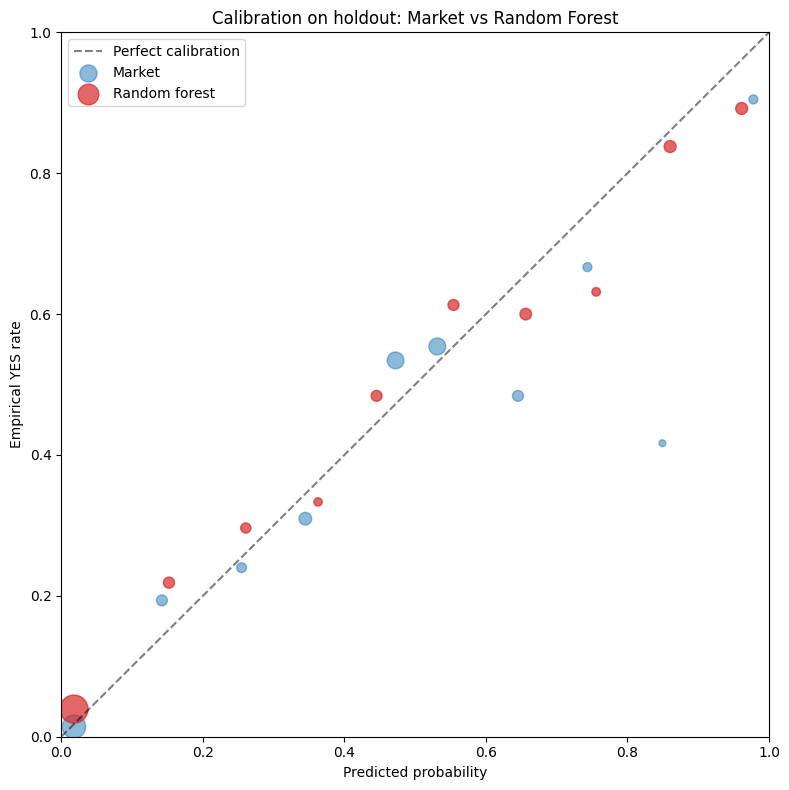

In [12]:
import matplotlib.pyplot as plt

bin_edges = np.linspace(0, 1, 11)

def calibration_curve(probs, y_true):
    bins = pd.cut(probs, bins=bin_edges, include_lowest=True)
    df_cal = pd.DataFrame({'p': probs, 'y': y_true.values, 'bin': bins})
    grouped = df_cal.groupby('bin', observed=True).agg(
        x=('p', 'mean'),
        empirical=('y', 'mean'),
        n=('y', 'size')
    ).reset_index()
    return grouped

market_cal = calibration_curve(market_probs, y_test)
rf_cal = calibration_curve(rf_probs, y_test)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.scatter(market_cal['x'], market_cal['empirical'],
           s=market_cal['n']*2, alpha=0.5, label='Market', color='C0')
ax.scatter(rf_cal['x'], rf_cal['empirical'],
           s=rf_cal['n']*2, alpha=0.7, label='Random forest', color='C3')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Empirical YES rate')
ax.set_title('Calibration on holdout: Market vs Random Forest')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Bootstrap Confidence Intervals on the per-category Brier score differences between the market and the model's scores

from sklearn.metrics import brier_score_loss

def bootstrap_brier_diff(y, market_p, model_p, n_boot=5000, seed=42);
    rng = np.random.default_rng(seed)
    n = len(y)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        y_boot = y[idx]
        if len(np.unique(y_boot)) < 2:
            continue
        diff = brier_score_loss(y_boot, market_p[idx]) - brier_score_loss(y_boot, model_p[idx])
        diffs.append(diff)
    diffs = np.array(diffs)
    
    return diffs.mean(), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)

## Findings

- Random forest achieves Brier 0.126 on a stratified holdout of 471 markets vs the 
  market's own Brier of 0.164 — a 23% improvement, beating the bar set in the methodology.
- Logistic regression baseline achieves Brier 0.162 (essentially tied with the market), 
  confirming the mispricing is nonlinear — the lift requires capturing category × price 
  interactions that a linear model can't.
- Per-category breakdown: improvement is concentrated in Crypto (−42% Brier) and 
  Sports (−16% Brier) — exactly the categories the calibration analysis flagged as 
  miscalibrated. Already-calibrated categories (Weather, Politics, Geopolitics) are 
  essentially untouched by the model.
- Feature importance: `prev_day_price` (50%), `volume` (30%), `lifetime_days` (10%). 
  Volume importance may be inflated by RF's bias toward high-cardinality features but 
  also plausibly reflects real signal (high-volume markets are better-priced).
- Limitations: stratified random split sacrifices "predicts future markets" framing. 
  Random forest is less interpretable than the linear baseline. No hyperparameter tuning.